In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

In [3]:
df = pd.read_csv("data.csv")

In [4]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [6]:
X = df.iloc[:, 0:3].values
y = df.iloc[:, -1].values

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [9]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Residual
y_predicted = lr.predict(X_test)
residual = y_predicted - y_test

## Linear Relationship

Text(0.5, 1.0, 'Feature 3')

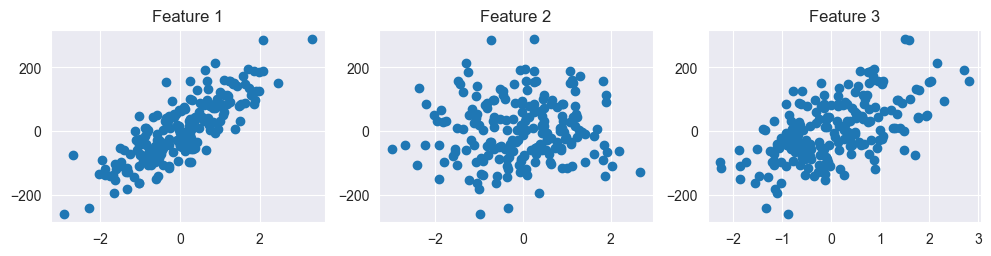

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=((12, 2.5)))

ax1.scatter(df["feature1"], df["target"])
ax1.set_title("Feature 1")
ax2.scatter(df["feature2"], df["target"])
ax2.set_title("Feature 2")
ax3.scatter(df["feature3"], df["target"])
ax3.set_title("Feature 3")

## Multicollinearity

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [13]:
vif

[np.float64(1.0015762358048874),
 np.float64(1.0011172482717838),
 np.float64(1.0019379434805475)]

In [14]:
pd.DataFrame({"vif": vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.001576,1.001117,1.001938


<Axes: >

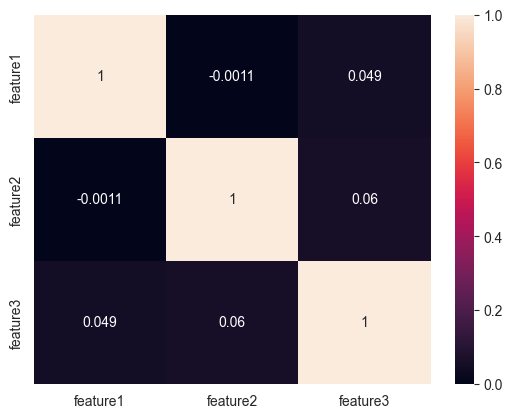

In [16]:
# Another technique
sns.heatmap(df.iloc[:, 0:3].corr(), annot=True)

## Normality of residual

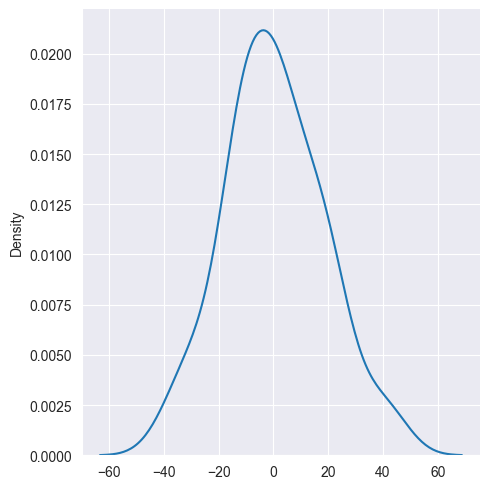

In [18]:
sns.displot(residual, kind="kde")

## Homoscedasticity

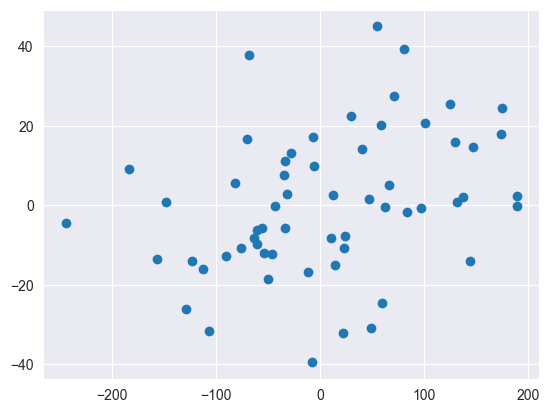

In [19]:
plt.scatter(y_predicted, residual)

## Autocorrelation of residuals

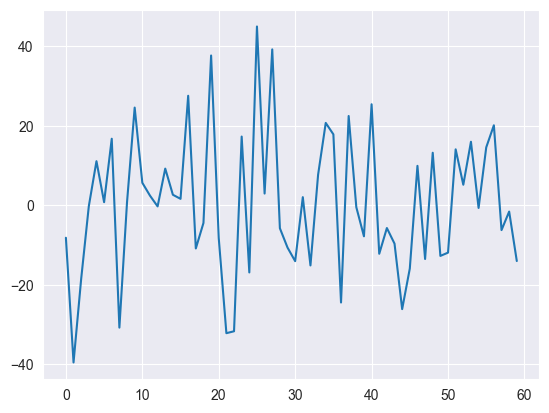

In [20]:
plt.plot(residual)